# Image Captioning on the Flicker8k Dataset

This notebook provides you with a rough structure for the Mini-Challenge on the topic of Image Captioning from the Deep Learning MSE course. Please make sure to follow the Project Setup steps to ensure reproducable results. Additionally familiarize yourself with the grading structure and project submission guidelines in the _DL-MPW-ImgCaptioning.pdf_ document. There you'll find all the information you should need. 

If you have any questions please contact roman.studer@fhnw.ch

###  Team Name and Members

Team Name: accidentally_studying

Team Members:
- Joël Thauss
- Maurizio Piu


### Some Guidelines

- You are allowed to use generative models (e.g. ChatGPT, Claude etc.) for code completion or suggestions. However, we require you to perfectly understand and control the code. 
- You are **not** allowed to use the same or similar generative models for providing reflection on the achieved results. __You__ must reflect about what you see and build your own opinion about it.
- You are allowed to create additional python scripts to outsource code snippets to improve readability.

## Project Setup


### 1. Create the virtual environment

Create a new environment and install the necessary dependencies listed in `requirements.txt`. Make sure you can import the libraries in the code cell below and that yout pytorch installation can run on your GPU.

In [88]:
# imports
import textwrap

import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision

from dataloader import build_tokenizer_from_split, create_caption_dataloader
from tokenizer import tokenize

print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

# TODO: Add your own imports here, if needed.
import torchvision.models as models
import torch.nn as nn
from tqdm import tqdm
from utils import save_checkpoint, load_checkpoint

# utils for bleu
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import torch.nn.functional as F
from torch.utils.data.dataloader import DataLoader
from tokenizer import CaptionTokenizer

torch version: 2.13.0.dev20260521+rocm7.2
torchvision version: 0.28.0.dev20260522+rocm7.2


In [89]:
# Check PyTorch + ROCm (AMD GPU) availability
print(f"\n\nPyTorch version: {torch.__version__}")
print(f"ROCm available: {torch.cuda.is_available()}")  # ROCm uses the CUDA API

if torch.cuda.is_available():
    print(f"GPU count: {torch.cuda.device_count()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

    # Run a quick tensor op on the GPU
    x = torch.tensor([1.0, 2.0, 3.0]).cuda()
    print(f"Tensor on GPU: {x}")
    print("✅ PyTorch is using your AMD GPU via ROCm!")
else:
    print("❌ No GPU detected.")



PyTorch version: 2.13.0.dev20260521+rocm7.2
ROCm available: True
GPU count: 2
GPU name: AMD Radeon RX 9070 XT
Tensor on GPU: tensor([1., 2., 3.], device='cuda:0')
✅ PyTorch is using your AMD GPU via ROCm!


### 2. Download the dataset
The Flickr8k dataset used in this challenge is available under [Flickr 8k Dataset - Kaggle](https://www.kaggle.com/datasets/adityajn105/flickr8k). In the zip folder on Moodle you find the basic structure with `captions.txt` and the `data/splits`-folder, but without images in the `data/ìmages`-folder. Make sure to download all the images and placing them in the folder `data/images/`. 
The train test split is already provided for you and handled by the provided `dataloader.py` script. Test and train split image lists and corresponding captions are located in the `data/splits/` folder. Don't modify this split.

<img src="data_structure.png"/>

## Dataloader, Tokenizer

The repository includes a `Dataset`-class (`Flickr8kCaptionsDatasetBase`) and `DataLoader`'s that are based on this specific structure of the data directory. You can use `create_caption_dataloader` for obtaining instances for the train and test data loaders. You can configure it with the `tokenizer` provided in the repo. The `tokenizer` performs some preprocessing steps of the captions. It also creates a vocabulary from the training data and then provides a mapping from the words to tokens. Note that there are also some special tokens introduced that are important when processing the captions during training or generating the captions during inference:
| Word    | ID | Role |
| --------| ---|----- |
| `<pad>`  | 0 | padding for filling up sequence to a given length in a mini-batch. | 
| `<bos>`  | 1 | beginning of sentence - each tokenized sentence should start with `<bos>`, i.e. also the generated ones. | 
| `<eos>`  | 2 | end of sentence - for fixed length captions will signal that the rest will consist of `<pad>`-tokens only. | 
| `<unk>`  | 3 | unknown - not available in vocabulary | 

Furthermore, specify your transforms used for preprocessing and augmenting the images and pass them to the `create_caption_dataloader`-method.
The mini-batches created by the dataloader have the following structure: `(images, captions, lengths, image_ids, raw_captions)`. Captions are built from the training vocabulary only, and `lengths` may let you mask padding tokens in the loss.


In [90]:
# Transforms
from torchvision import transforms

IMAGENET_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def _convert_to_rgb(image: Image.Image) -> Image.Image:
    return image.convert("RGB")


def build_train_transforms() -> transforms.Compose:
    return transforms.Compose(
        [
            transforms.Lambda(_convert_to_rgb),
            # START - MODIFY / EXTEND THIS PART
            transforms.Resize((IMAGENET_SIZE, IMAGENET_SIZE)),
            # END - MODIFY / EXTEND THIS PART
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ]
    )


def build_test_transforms() -> transforms.Compose:
    return transforms.Compose(
        [
            transforms.Lambda(_convert_to_rgb),
            transforms.Resize((IMAGENET_SIZE, IMAGENET_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ]
    )


def denormalize_image(image: torch.Tensor) -> torch.Tensor:
    """Undo ImageNet normalization for visualization."""
    mean_tensor = image.new_tensor(IMAGENET_MEAN).view(-1, 1, 1)
    std_tensor = image.new_tensor(IMAGENET_STD).view(-1, 1, 1)
    return (image * std_tensor + mean_tensor).clamp(0, 1)

In [91]:
# DONE: ADJUST PATH TO data_dir IF NEEDED
data_dir = "./data/"

# TODO: SET REASONABLE VALUES FOR THE FOLLOWING PARAMETERS
MIN_WORD_FREQ = 5
MAX_LEN = 40
BATCH_SIZE = 32

In [92]:
# TODO: POSSIBLY USE YOUR OWN TOKENIZER AND SET IT TO tokenizer=YourTokenizer(...)
# Make sure to build the vocabulary only from training captions to avoid test leakage.

tokenizer = build_tokenizer_from_split(
    split="train", data_dir=data_dir, min_freq=MIN_WORD_FREQ
)

train_loader = create_caption_dataloader(
    split="train",
    data_dir=data_dir,
    tokenizer=tokenizer,
    transform=build_train_transforms(),
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="all",
)
test_loader = create_caption_dataloader(
    split="test",
    data_dir=data_dir,
    tokenizer=tokenizer,
    transform=build_test_transforms(),
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="random",
)

images, captions, lengths, image_ids, raw_captions = next(iter(train_loader))

print(f"Vocabulary size: {len(tokenizer):,}")
print(f"Number of training examples: {len(train_loader.dataset):,}")
print(f"Batch image tensor shape: {tuple(images.shape)}")
print(f"Batch caption tensor shape: {tuple(captions.shape)}")
print(f"Caption lengths in first batch: {lengths.tolist()}")

images, captions, lengths, image_ids, raw_captions = next(iter(test_loader))

print(f"Number of test examples: {len(test_loader.dataset):,}")
print(f"Batch image tensor shape: {tuple(images.shape)}")
print(f"Batch caption tensor shape: {tuple(captions.shape)}")
print(f"Caption lengths in first batch: {lengths.tolist()}")

Vocabulary size: 2,649
Number of training examples: 32,365
Batch image tensor shape: (32, 3, 224, 224)
Batch caption tensor shape: (32, 40)
Caption lengths in first batch: [11, 15, 11, 14, 18, 9, 11, 13, 11, 9, 11, 11, 12, 19, 7, 14, 17, 12, 11, 14, 13, 12, 14, 14, 7, 10, 8, 10, 21, 14, 21, 15]
Number of test examples: 1,618
Batch image tensor shape: (32, 3, 224, 224)
Batch caption tensor shape: (32, 40)
Caption lengths in first batch: [21, 20, 18, 17, 12, 18, 9, 12, 7, 14, 18, 7, 9, 17, 10, 9, 12, 15, 14, 15, 12, 14, 7, 12, 19, 13, 9, 12, 13, 17, 10, 13]


INFO: The above code uses deprecated functionality, that throws warnings for the code call in dataloader.py:55

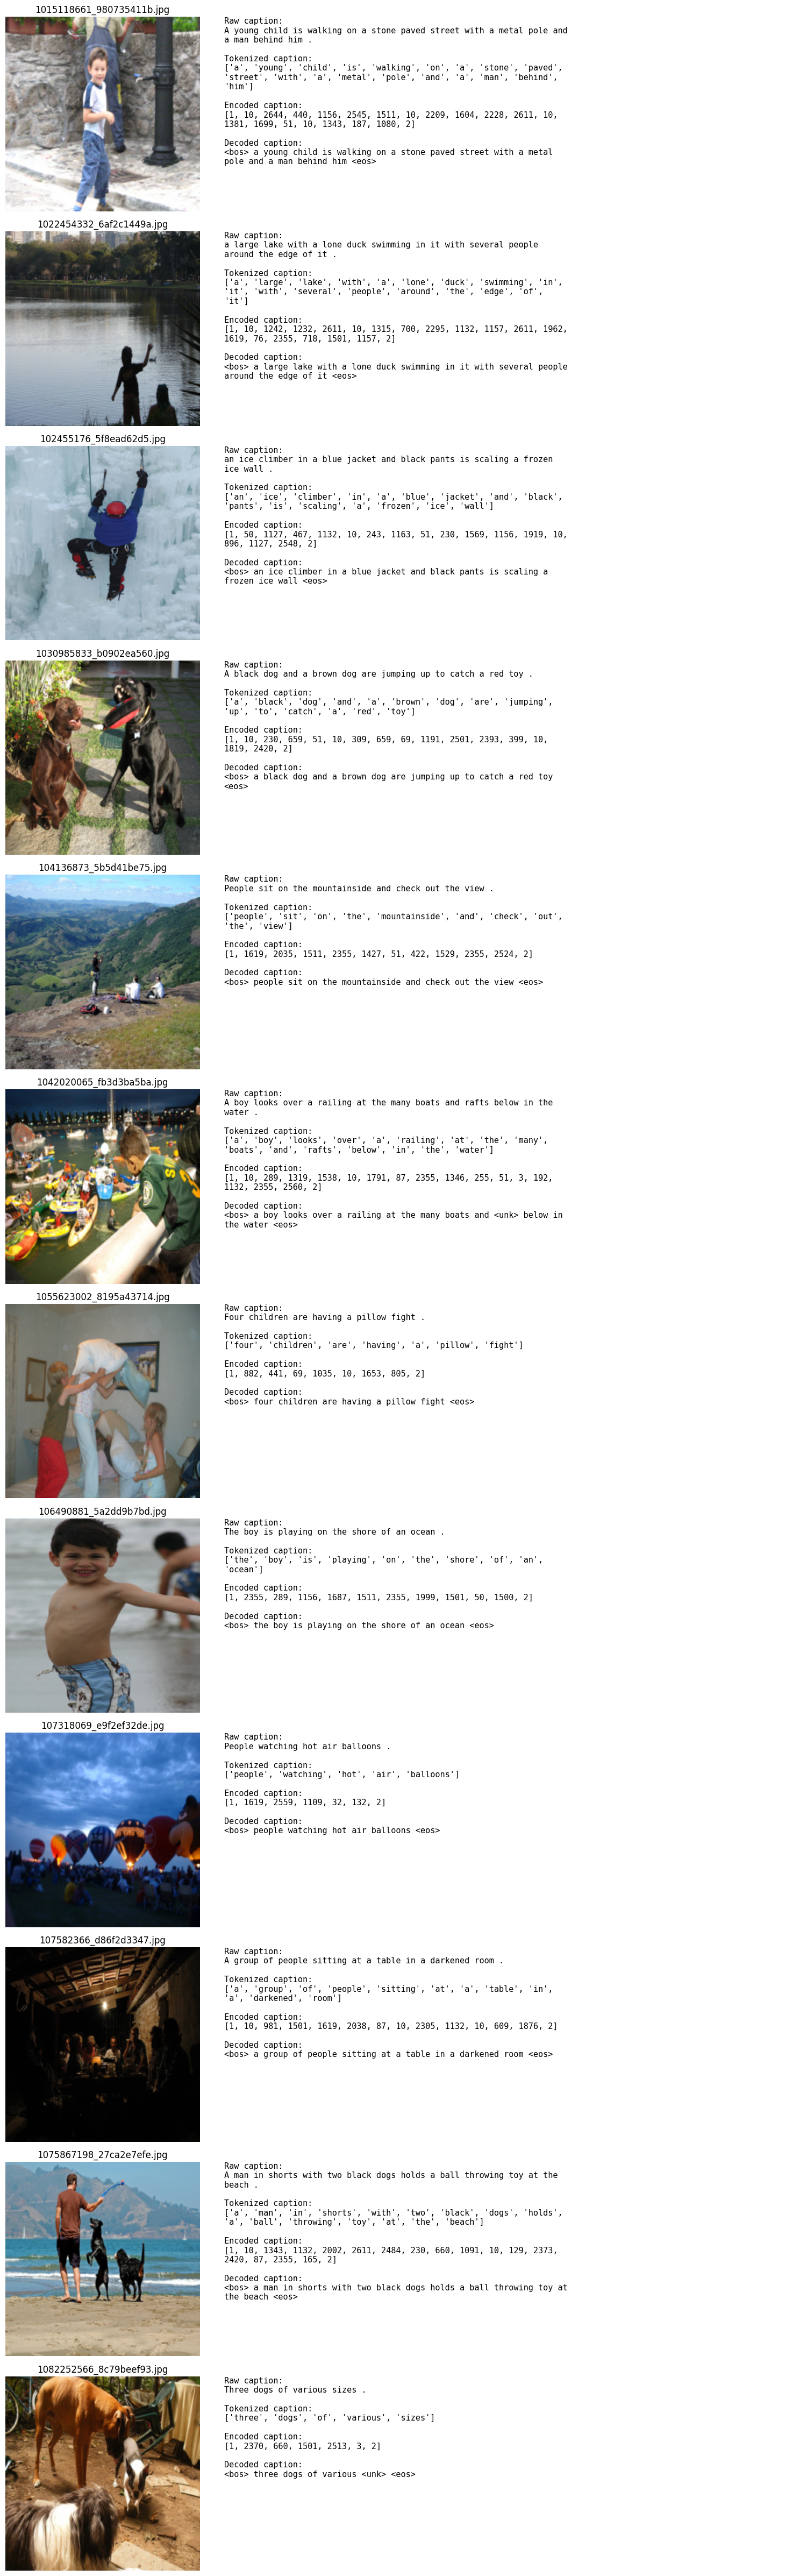

In [93]:
num_examples = 12
n = min(num_examples, len(images))

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(16, 4 * n),
    gridspec_kw={"width_ratios": [1.1, 2.2]},
)

if n == 1:
    axes = [axes]

for idx in range(n):
    image = denormalize_image(images[idx].detach().cpu()).permute(1, 2, 0)

    encoded_caption = captions[idx, : int(lengths[idx])].tolist()
    tokenized_caption = tokenize(raw_captions[idx])
    decoded_caption = tokenizer.decode(encoded_caption, skip_special_tokens=False)

    ax_image, ax_text = axes[idx]
    ax_image.imshow(image)
    ax_image.set_title(image_ids[idx])
    ax_image.axis("off")

    caption_details = "\n\n".join(
        [
            f"Raw caption:\n{textwrap.fill(raw_captions[idx], width=70)}",
            f"Tokenized caption:\n{textwrap.fill(str(tokenized_caption), width=70)}",
            f"Encoded caption:\n{textwrap.fill(str(encoded_caption), width=70)}",
            f"Decoded caption:\n{textwrap.fill(decoded_caption, width=70)}",
        ]
    )

    ax_text.axis("off")
    ax_text.text(
        0,
        1,
        caption_details,
        va="top",
        ha="left",
        fontsize=11,
        family="monospace",
    )

plt.tight_layout()
plt.show()

## Shared Utilities

Use this section for shared config and helper functions reused across all experiments. For example define a common training loop, BLEU computation or visualization helpers here. This way your model models stay directly comparable.


In [ ]:
# Define shared config, helper functions, a fixed evaluation subset, and BLEU computation.


DEVICE = None
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("device:", DEVICE)

# further helper functionality:


# TODO: Add the training loop, caption generation, evaluation and metric calculation logic for Model 1 here and in the following cells.


def train_show_and_tell(
    model: nn.Module,
    device: object,
    tokenizer: CaptionTokenizer,
    train_loader: DataLoader,
    test_loader: DataLoader,
    learning_rate: float = 3e-4,
    num_epochs: int = 5,
    calculate_bleu: bool = True,  # adds overhead cost
) -> tuple[nn.Module, dict]:
    """Runs the training loop and stores the metrics loss, and bleu as hisotry

    Args:
        model (nn.Module): torch model
        device (object): device on which the model should run
        tokenizer (CaptionTokenizer): the previously created tokenizer
        train_loader (DataLoader): -
        test_loader (DataLoader): -
        learning_rate (float, optional): Defaults to 3e-4.
        num_epochs (int, optional): number of training epochs. Defaults to 5.
        calculate_bleu (bool, optional): Wheter to calculate bleu score. Defaults to True.

    Returns:
        tuple[nn.Module, dict]: trained model, the history dictonary (one entry per epoch)
    """

    # Tracking of training history
    train_loss_history: list[float] = []
    train_bleu_1_history: list[float] = []
    train_bleu_2_history: list[float] = []
    test_loss_history: list[float] = []
    test_bleu_1_history: list[float] = []
    test_bleu_2_history: list[float] = []

    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_idx)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Freeze all ResNet layers except the new fc head
    for name, param in model.encoderCNN.resnet.named_parameters():
        param.requires_grad = "fc.weight" in name or "fc.bias" in name

    # training loop

    model.train()

    for epoch in range(num_epochs):
        total_loss = 0.0

        for imgs, captions, lengths, image_ids, raw_captions in tqdm(
            train_loader, leave=False
        ):
            imgs = imgs.to(device)
            captions = captions.to(device)
            captions = captions.T  # (B, T) ->(T, B)

            # forward pass with teacher forcing
            outputs = model(imgs, captions[:-1])  # outputs: (T, B, vocab_size)

            # outputs has T predictions; targets are the T tokens in captions
            loss = criterion(
                outputs.reshape(-1, outputs.shape[2]),  # (T*B, vocab_size)
                captions.reshape(-1),  # (T*B,)
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )  # gradient clipping to prevent exploding gradients
            optimizer.step()

            total_loss += loss.item()

        # calulate history metrics for later model evaluation
        avg_loss = total_loss / len(train_loader)
        train_loss_history.append(avg_loss)

        # eval loop
        model.eval()

        with torch.no_grad():
            total_loss_test = 0.0

            for imgs, captions, lengths, image_ids, raw_captions in tqdm(
                test_loader, leave=False
            ):
                imgs = imgs.to(device)
                captions = captions.to(device)
                captions = captions.T  # (B, T) ->(T, B)

                outputs = model(imgs, captions[:-1])  # outputs: (T, B, vocab_size)
                loss = criterion(
                    outputs.reshape(-1, outputs.shape[2]),  # (T*B, vocab_size)
                    captions.reshape(-1),  # (T*B,)
                )

            # calulate history metrics for later model evaluation
            avg_loss_test = total_loss_test / len(test_loader)
            test_loss_history.append(avg_loss_test)

        # calculate bleu for train and test
        if calculate_bleu:

            train_bleu: dict = evaluate_blue(model, train_loader, tokenizer)
            test_bleu: dict = evaluate_blue(model, train_loader, tokenizer)

            train_bleu_1_history.append(train_bleu["bleu_1"])
            train_bleu_1_history.append(train_bleu["bleu_2"])
            test_bleu_2_history.append(test_bleu["bleu_1"])
            test_bleu_2_history.append(test_bleu["bleu_2"])

    # compile history for easier handling
    history: dict = {
        "train_loss": train_loss_history,
        "train_bleu_1": train_bleu_1_history,
        "train_bleu_2": train_bleu_2_history,
        "test_loss": test_loss_history,
        "test_bleu_1": test_bleu_1_history,
        "test_bleu_2": test_bleu_2_history,
    }

    print(
        f"\n\nEpoch [{epoch+1}/{num_epochs}]\nTrain loss:\t{avg_loss:.4f}\nTest loss:\t{avg_loss_test:.4f}"
    )

    return model, history


def evaluate_blue(
    model: nn.Module,
    data_loader: DataLoader,
    tokenizer: CaptionTokenizer,
    device: torch.device = DEVICE,
) -> dict[str, float]:
    """Calculates the BLEU 1 and 2 scores, using the nltk library

    Args:
        model (ShowAndTellCaptioner): Model to eval
        data_loader (DataLoader): Pytorch data loader with the eval data
        tokenizer (CaptionTokenizer): The initialized tokenizer for the image captions
        device (torch.device, optional): Processing Device objectt. Defaults to DEVICE.

    Returns:
        dict[str, float]: the overall calculated "bleu_1" and "bleu_4" values
    """

    references: list[list[str]] = []
    hypotheses: list[list[str]] = []
    white_space_tokenize: list[str] = lambda string: string.lower().split(" ")

    # genereate the predictions in clear text, for later eval with bleu
    model.eval()
    with torch.no_grad():

        # batch
        for imgs, captions, lengths, image_ids, raw_captions in tqdm(
            data_loader, leave=False
        ):
            imgs: torch.tensor = imgs.to(DEVICE)
            captions: torch.tensor = captions.to(DEVICE)

            for i in range(lengths.size()[0]):

                # fetch and transform the data, generate caption
                img: torch.tensor = imgs[i].unsqueeze(0)
                caption: torch.tensor = tokenizer.decode(captions[i])
                img_id: torch.tensor = image_ids[i]
                hyp: str = model.generate(image=img)

                # apply tokenizer for blue eval
                references.append(white_space_tokenize(caption))
                hypotheses.append(white_space_tokenize(hyp))

    model.train()  # reset model to previous state to not create inconsistencies

    smoother = SmoothingFunction().method1
    bleu_1 = corpus_bleu(
        references,
        hypotheses,
        weights=(1.0, 0.0, 0.0, 0.0),
        smoothing_function=smoother,
    )
    bleu_2 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.5, 0.5, 0.0, 0.0),
        smoothing_function=smoother,
    )

    return {"bleu_1": bleu_1, "bleu_2": bleu_2}


def plot_history(history: dict[str, list]) -> None:
    """Uses the model history dict, generated by train_show_and_tell() to plot the history

    Args:
        history (dict[str, list]): Generated history by train_show_and_tell()
    """

    num_epochs: int = len(history["train_loss"])
    y: list[int] = range(1, num_epochs + 1, 1)

    # loss
    plt.figure(1)
    plt.plot(y, history["train_loss"], "b-", label="train")
    plt.plot(y, history["test_loss"], "r-", label="test")
    plt.title("loss")
    plt.legend()

    if len(history["train_bleu_1"]) > 0:

        for i in [1, 2]:
            plt.figure(i + 1)
            plt.plot(y, history[f"train_bleu_{i}"], "b-", label="train")
            plt.plot(y, history[f"test_bleu_{i}"], "r-", label="valid")
            plt.title(f"bleu_{i}")
            plt.legend()

    return


def random_samples(
    n: int, model: nn.Module, data_loader: DataLoader, tokenizer: CaptionTokenizer
) -> None:

    # conitue here
    return
    model.eval()
    with torch.no_grad():

        # batch
        for imgs, captions, lengths, image_ids, raw_captions in tqdm(
            data_loader, leave=False
        ):
            imgs: torch.tensor = imgs.to(DEVICE)
            captions: torch.tensor = captions.to(DEVICE)

            for i in range(lengths.size()[0]):

                # fetch and transform the data, generate caption
                img: torch.tensor = imgs[i].unsqueeze(0)
                caption: torch.tensor = tokenizer.decode(captions[i])
                img_id: torch.tensor = image_ids[i]
                hyp: str = model.generate(image=img)

                # apply tokenizer for blue eval
                references.append(white_space_tokenize(caption))
                hypotheses.append(white_space_tokenize(hyp))

    model.train()  # reset model to previous state to not create inconsistencies

device: cuda


## Model 1 - Show and Tell

Implement the model described in the [_Show and Tell_](https://arxiv.org/abs/1411.4555) paper . Record the training behavior, inspect a few generated captions on held-out images, and report BLEU on your fixed evaluation subset.

In [95]:
# TODO Implement the Show and Tell model classes and any model-specific setup here.

DROPOUT = 0.3


# a pretrained CNN encoder
class ShowAndTellEncoder(nn.Module):
    def __init__(self, embed_dim):
        super(ShowAndTellEncoder, self).__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Replace the classifier head: 512 → embed_dim
        resnet.fc = nn.Linear(resnet.fc.in_features, embed_dim)
        self.resnet = resnet
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        # images: (B, 3, 224, 224) → features: (B, embed_dim)
        features = self.resnet(images)
        return self.dropout(self.relu(features))


# an LSTM-based decoder
class ShowAndTellDecoder(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size, num_layers):
        super(ShowAndTellDecoder, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers)
        self.linear = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, features: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        # features: (B, embed_dim)
        # captions: (seq_len, B)  ← sequence-first
        embeddings = self.dropout(self.embed(captions))  # (seq_len, B, embed_dim)
        embeddings = torch.cat(
            (features.unsqueeze(0), embeddings), dim=0
        )  # (seq_len+1, B, embed_dim)
        hiddens, _ = self.lstm(embeddings)  # (seq_len+1, B, hidden_dim)
        outputs = self.linear(hiddens)  # (seq_len+1, B, vocab_size)
        return outputs


# Captioner: Connecting Encoder and Decoder
class ShowAndTellCaptioner(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size, num_layers):
        super(ShowAndTellCaptioner, self).__init__()
        self.encoderCNN = ShowAndTellEncoder(embed_dim)
        self.decoderRNN = ShowAndTellDecoder(
            embed_dim, hidden_dim, vocab_size, num_layers
        )

    def forward(self, images: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        # images: (B, 3, 224, 224)
        # captions: (seq_len, B) // already transposed before calling
        features = self.encoderCNN(images)  # (B, embed_dim)
        outputs = self.decoderRNN(features, captions)  # (seq_len+1, B, vocab_size)
        return outputs

    @torch.no_grad()
    def generate(self, image: torch.Tensor, max_len: int = 35) -> str:
        # image: (1, 3, 224, 224) — single image, batch size 1
        self.eval()
        result_ids = []

        # Encode image, treat as first LSTM input
        x = self.encoderCNN(image).unsqueeze(0)  # (1, 1, embed_dim)
        states = None

        for _ in range(max_len):
            hiddens, states = self.decoderRNN.lstm(
                x, states
            )  # hiddens: (1, 1, hidden_dim)
            output = self.decoderRNN.linear(hiddens.squeeze(0))  # (1, vocab_size)
            predicted = output.argmax(dim=1)  # (1,)

            token_id = predicted.item()
            if token_id == tokenizer.eos_idx:
                break

            result_ids.append(token_id)
            x = self.decoderRNN.embed(predicted).unsqueeze(0)  # (1, 1, embed_dim)

        return tokenizer.decode(result_ids)

In [96]:
# TODO Hyperparameters for the Show and Tell architecture
# ENCODER_DIM = 256 #
# EMBED_DIM = tokenizer.vocab_size # vocab size
# DECODER_DIM = 256 # hidden dim
# #FREEZE_ENCODER =

# Hyperparameters
embed_size = 256
hidden_size = 512
vocab_size = tokenizer.vocab_size
num_layers = 1
learning_rate = 3e-4
num_epochs = 5

In [ ]:
# TODO: Add the training loop, caption generation, evaluation and metric calculation logic for Model 1 here and in the following cells.
# runtime 6.5 min

model_1 = ShowAndTellCaptioner(embed_size, hidden_size, vocab_size, num_layers).to(
    DEVICE
)
model_1, history_1 = train_show_and_tell(
    model=model_1,
    device=DEVICE,
    tokenizer=tokenizer,
    train_loader=train_loader,
    test_loader=test_loader,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    calculate_bleu=False,  # ommited due to high cost
)



Epoch [5/5]
Train loss:	2.5869
Test loss:	0.0000


In [100]:
# fetch the last bleu values for eval
for ds, data_loader in zip(["train", "test"], [train_loader, test_loader]):

    bleu_sat_model: dict = evaluate_blue(
        model_1, data_loader=data_loader, tokenizer=tokenizer
    )

    print(f"{ds} bleu scores")
    for key in bleu_sat_model.keys():
        print(f"{key}:\t{bleu_sat_model[key]:.4f}")

train bleu scores
bleu_1:	0.0998
bleu_2:	0.0002


test bleu scores
bleu_1:	0.0980
bleu_2:	0.0008


ValueError: x and y must have same first dimension, but have shapes (5,) and (1,)

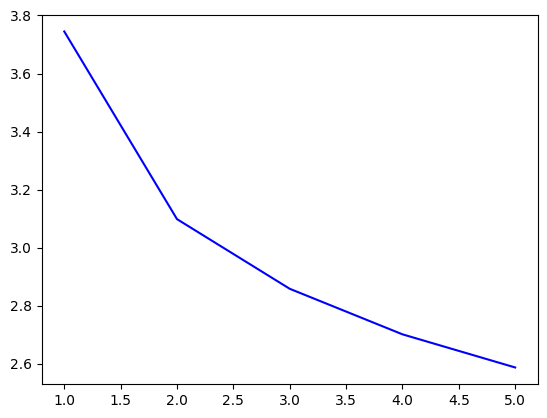

In [101]:
# plot the loss over the epochs for eval
plot_history(history_1)

In [ ]:
# ds_train = train_loader.dataset

"""
def train_show_and_tell():
    model = ShowAndTellCaptioner(embed_size, hidden_size, vocab_size, num_layers).to(
        DEVICE
    )
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_idx)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Freeze all ResNet layers except the new fc head
    for name, param in model.encoderCNN.resnet.named_parameters():
        param.requires_grad = "fc.weight" in name or "fc.bias" in name

    model.train()

    # tracking of training history
    loss_history: list[float] = []
    bleu_history: list[float] = []

    for epoch in range(num_epochs):
        total_loss = 0.0

        for imgs, captions, lengths, image_ids, raw_captions in tqdm(
            train_loader, leave=False
        ):
            imgs = imgs.to(DEVICE)
            captions = captions.to(DEVICE)
            captions = captions.T  # (B, T) ->(T, B)

            # forward pass with teacher forcing
            outputs = model(imgs, captions[:-1])  # outputs: (T, B, vocab_size)

            # outputs has T predictions; targets are the T tokens in captions
            loss = criterion(
                outputs.reshape(-1, outputs.shape[2]),  # (T*B, vocab_size)
                captions.reshape(-1),  # (T*B,)
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )  # gradient clipping to prevent exploding gradients
            optimizer.step()

            total_loss += loss.item()

        # calulate history metrics for later model evaluation
        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

    return model, history


sat_model = train_show_and_tell()

# looking at the bleu scores

for ds, data_loader in zip(["train", "test"], [train_loader, test_loader]):

    bleu_sat_model: dict = evaluate_blue(
        sat_model, data_loader=data_loader, tokenizer=tokenizer
    )

    print(f"{ds} bleu scores")
    for key in bleu_sat_model.keys():
        print(f"{key}:\t{bleu_sat_model[key]:.4f}")
"""

In [ ]:
# looking at some generated images:

Briefly summarize what happened during training, which captions looked convincing or weak, and what the BLEU score does or does not capture for this model.


<i>See: <a href="https://www.rws.com/blog/understanding-mt-quality-bleu-scores/">Understanding machine translation Quality: BLEU scores</a></i>


## Model 2 - Show, Attend and Tell

Now implement the continuation of the Show and Tell paper. An attention-based captioning model described in the paper [_Show, Attend and Tell_](https://arxiv.org/abs/1502.03044). Use the same test data subset and BLEU setup as before, then compare how attention changes the training behavior and generated captions.


In [ ]:
# TODO Parameters for the Show, Attend and Tell Architecture
ENCODER_DIM = 
EMBED_DIM = 
DECODER_DIM = 
DROPOUT = 
FREEZE_ENCODER = 
ATTENTION_DIM = 

In [ ]:
class ShowAttendTellEncoder(nn.Module):
    def __init__(self, ...):
        # TODO
    def forward(self, images: torch.Tensor) -> torch.Tensor:
        # TODO


class AdditiveAttention(nn.Module):
    def __init__(self, ....):
        # TODO
    def forward(self, encoder_out: torch.Tensor, decoder_hidden: torch.Tensor):
        # encoder_out: (B, num_pixels, encoder_dim)
        # decoder_hidden: (B, decoder_dim)
        # TODO

class ShowAttendTellCaptioner(nn.Module):
    def __init__(self, ...):
        # TODO

    def forward(self, images: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        # TODO

    @torch.no_grad()
    def generate(self, images: torch.Tensor, max_len=35) -> torch.Tensor:
        # TODO

In [ ]:
# TODO: Add the training loop, caption generation, evaluation and metric calculation logic for Model 2 here and in the following cells.

Briefly summarize how this model behaved during training, where attention seemed to help or fail, and how the BLEU score compares to Model 2.


<span style="color: red;"><strong>TODO:</strong> Write your reflection on Model 2 here.</span>


## Additional Task 1: Option ...

Formulate and rationalize a hypothesis.

Carry through an experiment for testing this hypothesis.

Describe the outcome and carefully evaluate and reflect about it. 

## Additional Task 2: Option ....

Formulate and rationalize a hypothesis.

Carry through an experiment for testing this hypothesis.

Describe the outcome and carefully evaluate and reflect about it. 